# Ejercicio 1 - Red neuronal para predecir la resistencia a compresión del concreto

## Enunciado
Tomar una tabla de datos de un experimento cualquiera, encontrar un modelo basado en una red neuronal de **dos capas ocultas** y darle datos al modelo para realizar una predicción.

## Dataset
Se utiliza **Concrete Compressive Strength**, un conjunto de datos experimental de UCI. Tiene 1030 observaciones, 8 variables de entrada y una variable objetivo: resistencia a compresión del concreto en MPa.

La red se plantea como un problema de **regresión**. Se normalizan las variables, se divide el conjunto en entrenamiento y prueba y se utiliza una red neuronal con dos capas ocultas.

In [3]:
# Si es necesario, instalar:
!pip install ucimlrepo tensorflow scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# Descargar el dataset desde UCI
dataset = fetch_ucirepo(id=165)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
display(X.head())
display(y.head())

Dimensiones de X: (1030, 8)
Dimensiones de y: (1030, 1)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


,Concrete compressive strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30


In [5]:
# Nombres de variables
print("Características:")
print(X.columns.tolist())
print("\nVariable objetivo:")
print(y.columns.tolist())

display(X.describe().T)
display(y.describe().T)

Características:
['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']

Variable objetivo:
['Concrete compressive strength']


,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.167864,104.506364,102.0,192.375,272.9,350.00,540.0
Blast Furnace Slag,1030.0,73.895825,86.279342,0.0,0.000,22.0,142.95,359.4
Fly Ash,1030.0,54.188350,63.997004,0.0,0.000,0.0,118.30,200.1
Water,1030.0,181.567282,21.354219,121.8,164.900,185.0,192.00,247.0
Superplasticizer,1030.0,6.204660,5.973841,0.0,0.000,6.4,10.20,32.2
Coarse Aggregate,1030.0,972.918932,77.753954,801.0,932.000,968.0,1029.40,1145.0
Fine Aggregate,1030.0,773.580485,80.175980,594.0,730.950,779.5,824.00,992.6
Age,1030.0,45.662136,63.169912,1.0,7.000,28.0,56.00,365.0


,count,mean,std,min,25%,50%,75%,max
Concrete compressive strength,1030.0,35.817961,16.705742,2.33,23.71,34.445,46.135,82.6


## Preparación de los datos

La red recibe las ocho características del concreto. Se separan los datos en entrenamiento y prueba. La estandarización se ajusta únicamente con el conjunto de entrenamiento para evitar fuga de información.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Entrenamiento:", X_train_s.shape)
print("Prueba:", X_test_s.shape)

Entrenamiento: (824, 8)
Prueba: (206, 8)


## Modelo con dos capas ocultas

Se construye una red feedforward con:

- Entrada: 8 características.
- Primera capa oculta: 32 neuronas, ReLU.
- Segunda capa oculta: 16 neuronas, ReLU.
- Salida: 1 neurona lineal para la resistencia.
- Pérdida: error cuadrático medio (MSE).
- Optimizador: Adam.

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_s.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.20,
    epochs=500,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print("Épocas ejecutadas:", len(history.history["loss"]))

Épocas ejecutadas: 420


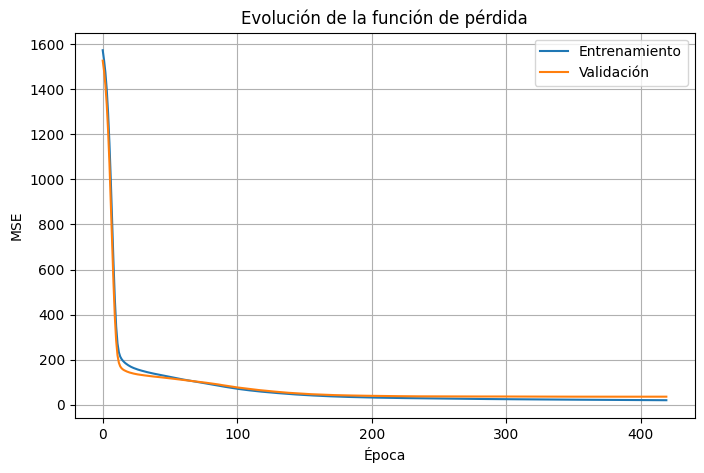

In [9]:
# Evolución de la pérdida
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución de la función de pérdida")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Evaluación
y_pred = model.predict(X_test_s, verbose=0).ravel()
y_true = y_test.to_numpy().ravel()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE  = {mae:.3f} MPa")
print(f"RMSE = {rmse:.3f} MPa")
print(f"R²   = {r2:.3f}")

MAE  = 4.756 MPa
RMSE = 6.297 MPa
R²   = 0.846


,Real (MPa),Predicción (MPa),Error absoluto (MPa)
0,52.91,42.226192,10.683808
1,55.90,44.649525,11.250475
2,74.50,69.006851,5.493149
3,35.30,40.823853,5.523853
4,10.54,15.460831,4.920831
5,44.28,47.357716,3.077716
6,23.69,25.705925,2.015925
7,45.37,52.549431,7.179431
8,37.40,33.773769,3.626231
9,48.85,47.994274,0.855726


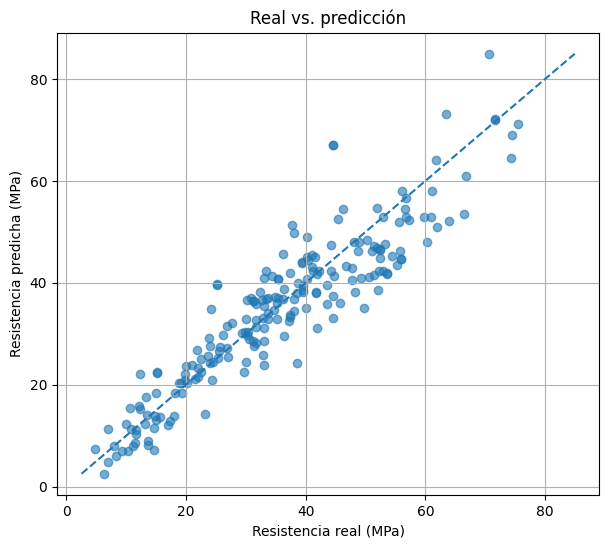

In [11]:
# Comparación entre valores reales y predichos
resultados = pd.DataFrame({
    "Real (MPa)": y_true,
    "Predicción (MPa)": y_pred,
    "Error absoluto (MPa)": np.abs(y_true - y_pred)
})

display(resultados.head(15))

plt.figure(figsize=(7,6))
plt.scatter(y_true, y_pred, alpha=0.6)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, "--")
plt.xlabel("Resistencia real (MPa)")
plt.ylabel("Resistencia predicha (MPa)")
plt.title("Real vs. predicción")
plt.grid(True)
plt.show()

## Predicción para un nuevo conjunto de datos

A continuación se selecciona una muestra del conjunto de prueba como ejemplo de entrada. También puede reemplazarse por una combinación nueva de valores de las ocho características.

In [12]:
# Ejemplo de entrada: se toma una muestra del conjunto de prueba
nuevo = X_test.iloc[[0]].copy()

prediccion = model.predict(
    scaler.transform(nuevo), verbose=0
)[0,0]

print("Datos de entrada:")
display(nuevo)
print(f"Resistencia a compresión predicha: {prediccion:.2f} MPa")

Datos de entrada:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
31,266.0,114.0,0.0,228.0,0.0,932.0,670.0,365


Resistencia a compresión predicha: 42.23 MPa


## Conclusión

La red neuronal de dos capas ocultas permite modelar la relación no lineal entre la composición/edad del concreto y su resistencia a compresión. El desempeño debe evaluarse con MAE, RMSE y R² sobre datos que no participaron en el entrenamiento. La predicción final muestra cómo el modelo puede utilizarse con un nuevo conjunto de características.